In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import warnings

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [51]:
stock   = pd.read_csv('stock_data.csv')
cpi     = pd.read_csv('CPIAUCSL.csv')
dgs10   = pd.read_csv('DGS10.csv')
fedfund = pd.read_csv('FEDFUNDS.csv')
unrate  = pd.read_csv('UNRATE.csv')

print(f"   stock_data  : {stock.shape}")
print(f"   CPIAUCSL    : {cpi.shape}")
print(f"   DGS10       : {dgs10.shape}")
print(f"   FEDFUNDS    : {fedfund.shape}")
print(f"   UNRATE      : {unrate.shape}")


   stock_data  : (1444, 7)
   CPIAUCSL    : (200, 2)
   DGS10       : (4066, 2)
   FEDFUNDS    : (193, 2)
   UNRATE      : (188, 2)


In [52]:
stock.columns = [c.strip().replace(' ', '_') for c in stock.columns]
print(f"  stock columns (fixed): {list(stock.columns)}")

  stock columns (fixed): ['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume']


In [53]:
if 'Date' in stock.columns:
    stock['Date'] = pd.to_datetime(stock['Date'], dayfirst=True, errors='coerce')
    stock = stock.set_index('Date').sort_index()
else: # 'Date' is likely already the index, just ensure it's datetime and sorted
    stock.index = pd.to_datetime(stock.index, dayfirst=True, errors='coerce')
    stock = stock.sort_index()

# Process other dataframes (cpi, dgs10, fedfund, unrate)
for df_name in ['cpi', 'dgs10', 'fedfund', 'unrate']:
    df = globals()[df_name] # Get the dataframe by its name

    # Check if 'observation_date' column exists, then rename to 'Date'
    if 'observation_date' in df.columns:
        df.rename(columns={'observation_date': 'Date'}, inplace=True)

    # Now, handle the 'Date' column or index
    if 'Date' in df.columns:
        if df_name == 'fedfund':
            # For fedfund, format is DD/MM/YYYY
            df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
        else:
            # For cpi, dgs10, unrate, dates are YYYY-MM-DD, pandas can infer well
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df = df.set_index('Date').sort_index()
    elif isinstance(df.index, pd.DatetimeIndex): # If 'Date' is already the index and is Datetime
        df = df.sort_index()
    else: # If 'Date' is already the index but not Datetime, convert it
        if df_name == 'fedfund':
            df.index = pd.to_datetime(df.index, format='%d/%m/%Y', errors='coerce')
        else:
            df.index = pd.to_datetime(df.index, errors='coerce')
        df = df.sort_index()

    globals()[df_name] = df # Update the global dataframe

In [54]:
print(f"  DGS10 NaN before   : {dgs10['DGS10'].isnull().sum()}")
print(f"  CPI   NaN before   : {cpi['CPIAUCSL'].isnull().sum()}")

dgs10['DGS10']   = dgs10['DGS10'].ffill()
cpi['CPIAUCSL']  = cpi['CPIAUCSL'].interpolate(method='linear')



  DGS10 NaN before   : 167
  CPI   NaN before   : 1


In [55]:
trading_dates = stock.index   # 1444 actual trading days

def align_to_trading(df):

    return df.reindex(trading_dates, method='ffill')

cpi_a   = align_to_trading(cpi)
fed_a   = align_to_trading(fedfund)
un_a    = align_to_trading(unrate)
dgs10_a = align_to_trading(dgs10)

print(f"  CPI aligned     : {cpi_a.shape}   NaN: {cpi_a.isnull().sum().sum()}")
print(f"  FEDFUNDS aligned: {fed_a.shape}   NaN: {fed_a.isnull().sum().sum()}")
print(f"  UNRATE aligned  : {un_a.shape}    NaN: {un_a.isnull().sum().sum()}")
print(f"  DGS10 aligned   : {dgs10_a.shape} NaN: {dgs10_a.isnull().sum().sum()}")


  CPI aligned     : (1444, 1)   NaN: 0
  FEDFUNDS aligned: (1444, 1)   NaN: 0
  UNRATE aligned  : (1444, 1)    NaN: 0
  DGS10 aligned   : (1444, 1) NaN: 0


In [56]:
stock.drop(columns=['Close'], inplace=True)

master = stock.copy()
master = master.join(dgs10_a)
master = master.join(cpi_a)
master = master.join(fed_a)
master = master.join(un_a)

print(f"  Shape  : {master.shape}")
print(f"  Columns: {list(master.columns)}")
print(f"  NaN    : {master.isnull().sum().sum()}")
print(master.head(3).to_string())


  Shape  : (1444, 9)
  Columns: ['Adj_Close', 'High', 'Low', 'Open', 'Volume', 'DGS10', 'CPIAUCSL', 'FEDFUNDS', 'UNRATE']
  NaN    : 0
            Adj_Close       High        Low       Open     Volume  DGS10  CPIAUCSL  FEDFUNDS  UNRATE
Date                                                                                                
2019-05-10  41.570000  45.000000  41.060001  42.000000  186322500   2.47    258.63      2.39     3.6
2019-05-13  37.099998  39.240002  36.080002  38.790001   79442400   2.40    258.63      2.39     3.6
2019-05-14  39.959999  39.959999  36.849998  38.310001   46661100   2.42    258.63      2.39     3.6


# Feature Engineering

In [57]:
P = 'Adj_Close'   # price alias — no spaces, safe in all editors

# 1. Returns & Target
master['Log_Return']      = np.log(master[P] / master[P].shift(1))
master['Volatility_21d']  = master['Log_Return'].rolling(21).std() * np.sqrt(252)

# 2. Multi-horizon volatility
master['Volatility_5d']   = master['Log_Return'].rolling(5).std()  * np.sqrt(252)
master['Volatility_63d']  = master['Log_Return'].rolling(63).std() * np.sqrt(252)

# 3. Lagged volatility
master['Vol_lag1']        = master['Volatility_21d'].shift(1)
master['Vol_lag5']        = master['Volatility_21d'].shift(5)
master['Vol_lag21']       = master['Volatility_21d'].shift(21)

# 4. Market features
master['Daily_Range']     = (master['High'] - master['Low']) / master[P]
master['Momentum_5d']     = master[P].pct_change(5)
master['Momentum_21d']    = master[P].pct_change(21)
master['MA_5']            = master[P].rolling(5).mean()
master['MA_21']           = master[P].rolling(21).mean()
master['MA_ratio']        = master['MA_5'] / master['MA_21']
master['Volume_MA5']      = master['Volume'].rolling(5).mean()
master['Volume_ratio']    = master['Volume'] / master['Volume_MA5']

# 5. Macro derived
master['CPI_MoM']         = master['CPIAUCSL'].pct_change(21)
master['Yield_Spread']    = master['DGS10'] - master['FEDFUNDS']
master['Rate_Change']     = master['FEDFUNDS'].diff(21)

# Drop NaN rows produced by rolling windows (first ~63 rows)
mc = master.dropna().copy()

print(f"  Rows before dropna : {len(master)}")
print(f"  Rows after  dropna : {len(mc)}")
print(f"  Total columns      : {mc.shape[1]}")
print(f"  NaN remaining      : {mc.isnull().sum().sum()}")
print(f"\n  All columns:")
for c in mc.columns:
    print(f"    {c}")

  Rows before dropna : 1444
  Rows after  dropna : 1381
  Total columns      : 27
  NaN remaining      : 0

  All columns:
    Adj_Close
    High
    Low
    Open
    Volume
    DGS10
    CPIAUCSL
    FEDFUNDS
    UNRATE
    Log_Return
    Volatility_21d
    Volatility_5d
    Volatility_63d
    Vol_lag1
    Vol_lag5
    Vol_lag21
    Daily_Range
    Momentum_5d
    Momentum_21d
    MA_5
    MA_21
    MA_ratio
    Volume_MA5
    Volume_ratio
    CPI_MoM
    Yield_Spread
    Rate_Change


# Explotary data Analysis

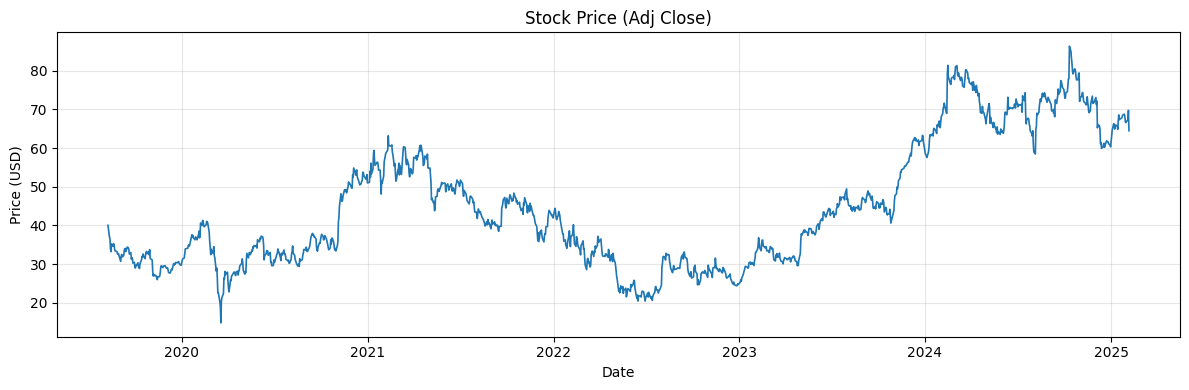

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(mc.index, mc[P], linewidth=1.2)
plt.title("Stock Price (Adj Close)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

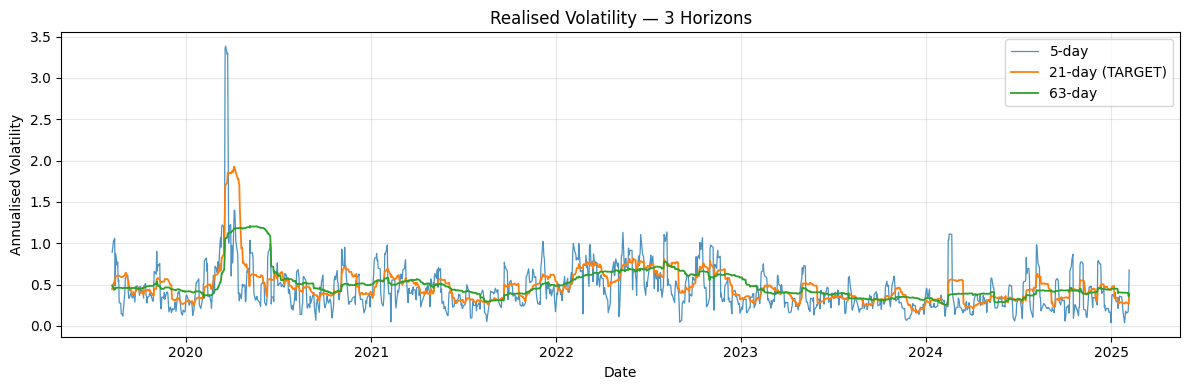

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(mc.index, mc["Volatility_5d"],  linewidth=0.9, label="5-day", alpha=0.8)
plt.plot(mc.index, mc["Volatility_21d"], linewidth=1.3, label="21-day (TARGET)")
plt.plot(mc.index, mc["Volatility_63d"], linewidth=1.3, label="63-day")
plt.title("Realised Volatility — 3 Horizons")
plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

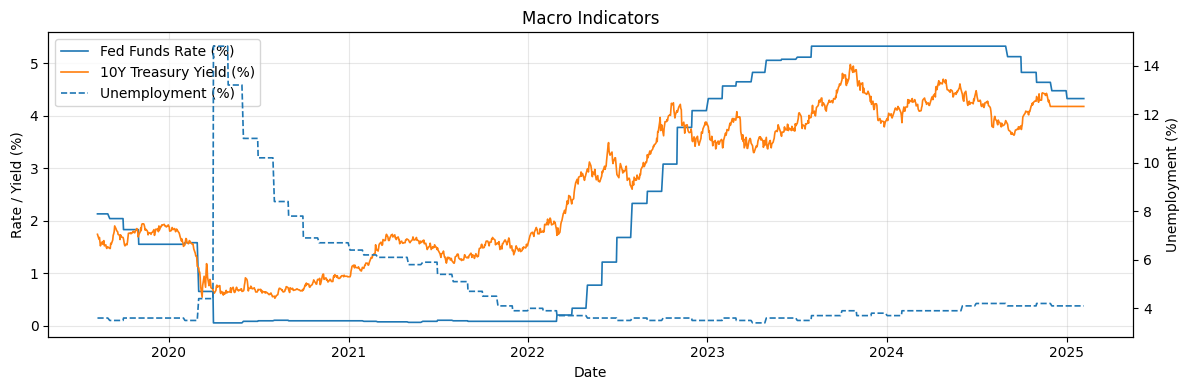

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax2 = ax.twinx()

ax.plot(mc.index, mc["FEDFUNDS"], linewidth=1.2, label="Fed Funds Rate (%)")
ax.plot(mc.index, mc["DGS10"],    linewidth=1.2, label="10Y Treasury Yield (%)")
ax2.plot(mc.index, mc["UNRATE"],  linewidth=1.2, linestyle="--", label="Unemployment (%)")

ax.set_title("Macro Indicators")
ax.set_xlabel("Date")
ax.set_ylabel("Rate / Yield (%)")
ax2.set_ylabel("Unemployment (%)")

# combine legends from both axes
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")

ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

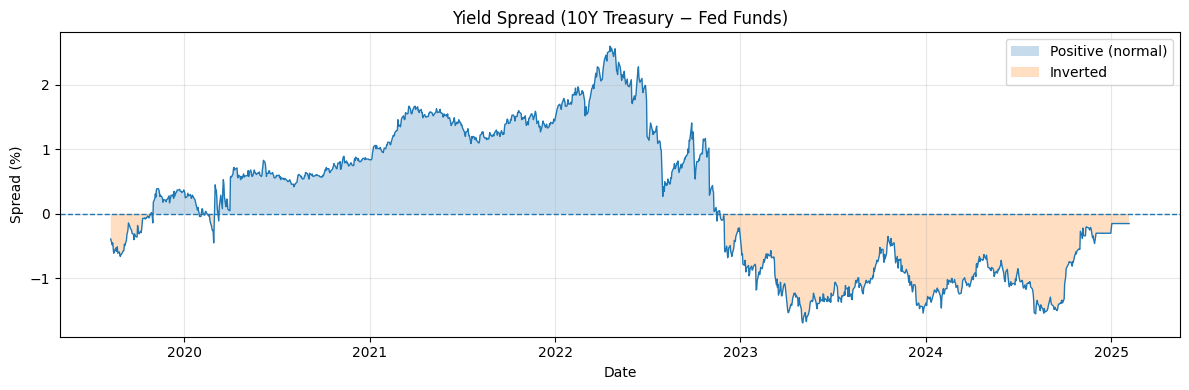

In [61]:
import matplotlib.pyplot as plt

y = mc["Yield_Spread"]

plt.figure(figsize=(12, 4))
plt.plot(mc.index, y, linewidth=1.0)

plt.fill_between(mc.index, y, 0, where=(y > 0),  alpha=0.25, label="Positive (normal)")
plt.fill_between(mc.index, y, 0, where=(y <= 0), alpha=0.25, label="Inverted")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Yield Spread (10Y Treasury − Fed Funds)")
plt.xlabel("Date")
plt.ylabel("Spread (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [63]:
FEATURES = [
    'Vol_lag1',   'Vol_lag5',     'Vol_lag21',
    'Volatility_5d', 'Volatility_63d',
    'Daily_Range','Volume_ratio',
    'Momentum_5d','Momentum_21d', 'MA_ratio',    'Log_Return',
    'DGS10',      'FEDFUNDS',     'CPIAUCSL',    'UNRATE',
    'CPI_MoM',    'Yield_Spread', 'Rate_Change'
]
TARGET = 'Volatility_21d'


# Train / Test

In [64]:
split_idx  = int(len(mc) * 0.80)

X_train    = mc[FEATURES].iloc[:split_idx].values
X_test     = mc[FEATURES].iloc[split_idx:].values
y_train    = mc[TARGET].iloc[:split_idx].values
y_test     = mc[TARGET].iloc[split_idx:].values
dates_test = mc.index[split_idx:]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)         # apply train stats to test

print(f"  Total rows : {len(mc)}")
print(f"  Train rows : {len(X_train)}  ({mc.index[0].date()} to {mc.index[split_idx-1].date()})")
print(f"  Test  rows : {len(X_test)}   ({mc.index[split_idx].date()} to {mc.index[-1].date()})")


  Total rows : 1381
  Train rows : 1104  (2019-08-09 to 2023-12-27)
  Test  rows : 277   (2023-12-28 to 2025-02-05)


# SARIMAX

In [65]:
# SARIMAX model with exogenous variables
sarimax_model = SARIMAX(
    y_train_ts,
    exog=X_train_exog,
    order=(2, 0, 2),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

# Forecast
sarimax_forecast_values = sarimax_fit.forecast(
    steps=len(y_test_ts),
    exog=X_test_exog
).values # Extract values to avoid index mismatch

sarimax_pred = pd.Series(sarimax_forecast_values, index=y_test_ts.index)

# Evaluation
sarimax_rmse, sarimax_mae, sarimax_r2 = evaluate_timeseries_model(
    "SARIMAX(2,0,2)", y_test_ts, sarimax_pred
)

SARIMAX(2,0,2)
RMSE : 0.031940
MAE  : 0.020454
R2   : 0.905419
----------------------------------------


## ARIMA model

In [66]:
# ARIMA model
arima_model = ARIMA(y_train_ts, order=(2, 0, 2))
arima_fit = arima_model.fit()

# Forecast for test period
arima_forecast_values = arima_fit.forecast(steps=len(y_test_ts)).values

# Convert to pandas Series for easy plotting
arima_pred = pd.Series(arima_forecast_values, index=y_test_ts.index)

# Evaluation
arima_rmse, arima_mae, arima_r2 = evaluate_timeseries_model(
    "ARIMA(2,0,2)", y_test_ts, arima_pred
)

ARIMA(2,0,2)
RMSE : 0.153090
MAE  : 0.128653
R2   : -1.172789
----------------------------------------


In [67]:

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)
print("R2   :", rf_r2)

RMSE : 0.03443383379839496
MAE  : 0.01707474033431141
R2   : 0.8900758178443673


In [68]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_r2   = r2_score(y_test, gb_pred)

print("RMSE :", gb_rmse)
print("MAE  :", gb_mae)
print("R2   :", gb_r2)

RMSE : 0.027273089747323162
MAE  : 0.015350199281656056
R2   : 0.9310409661001267


# Comparision of all models

In [84]:
# Create DataFrame storing all model metrics
all_metrics = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "ARIMA(2,0,2)",
        "SARIMAX(2,0,2)"
    ],

    "RMSE": [
        rf_rmse,
        gb_rmse,
        arima_rmse,
        sarimax_rmse
    ],

    "MAE": [
        rf_mae,
        gb_mae,
        arima_mae,
        sarimax_mae
    ],

    "R2 Score": [
        rf_r2,
        gb_r2,
        arima_r2,
        sarimax_r2
    ]
})

In [86]:
# Sort models by best R2 Score
all_metrics = all_metrics.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("\n Model Performance Comparison ")
print(all_metrics.to_string())


 Model Performance Comparison 
               Model      RMSE       MAE  R2 Score
0  Gradient Boosting  0.027273  0.015350  0.931041
1     SARIMAX(2,0,2)  0.031940  0.020454  0.905419
2      Random Forest  0.034434  0.017075  0.890076
3       ARIMA(2,0,2)  0.153090  0.128653 -1.172789


In [90]:
# Select best model based on highest R2 Score
best_model_name = all_metrics.loc[0, "Model"]

print("Best model based on R² Score:", best_model_name)

Best model based on R² Score: Gradient Boosting


In [92]:
# Store predictions in a dictionary
pred_dict = {
    "Random Forest": pd.Series(rf_pred, index=dates_test),
    "Gradient Boosting": pd.Series(gb_pred, index=dates_test),
    "ARIMA(2,0,2)": pd.Series(arima_pred, index=y_test_ts.index),
    "SARIMAX(2,0,2)": pd.Series(sarimax_pred, index=y_test_ts.index)
}

# Choose best prediction
best_pred = pred_dict[best_model_name]

print("Prediction series selected for:", best_model_name)

Prediction series selected for: Gradient Boosting


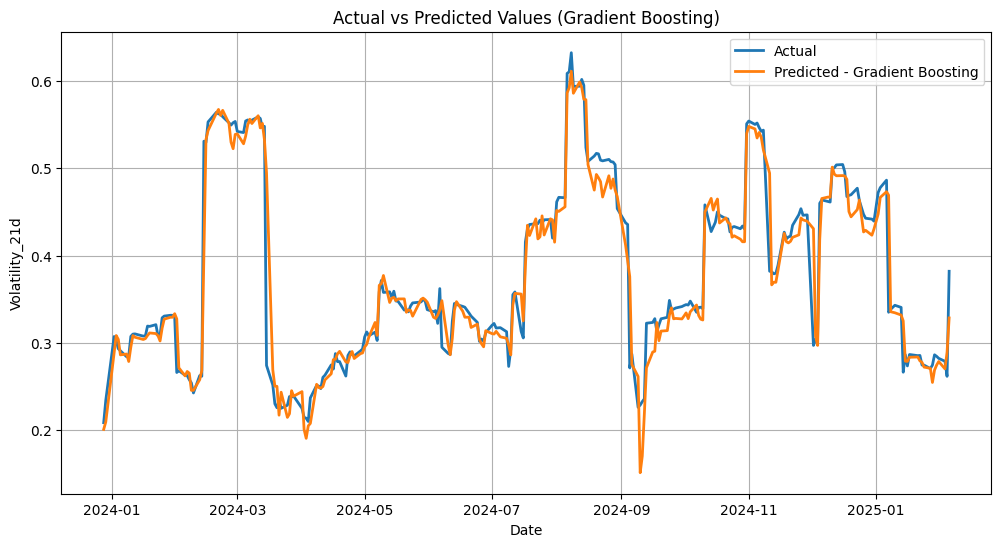

In [94]:
plt.figure(figsize=(12, 6))

plt.plot(dates_test, y_test, label="Actual", linewidth=2)
plt.plot(best_pred.index, best_pred, label=f"Predicted - {best_model_name}", linewidth=2)

plt.title(f"Actual vs Predicted Values ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Volatility_21d")
plt.legend()
plt.grid(True)
plt.show()

In [96]:
# Align actual and predicted values safely
actual_aligned = pd.Series(y_test, index=dates_test) # Convert y_test to a Series with the correct index
pred_aligned = best_pred.reindex(actual_aligned.index)

# Residuals
residuals = actual_aligned - pred_aligned

print(residuals.head())

Date
2023-12-28    0.007713
2023-12-29    0.024748
2024-01-02    0.018041
2024-01-03   -0.006100
2024-01-04   -0.010663
dtype: float64


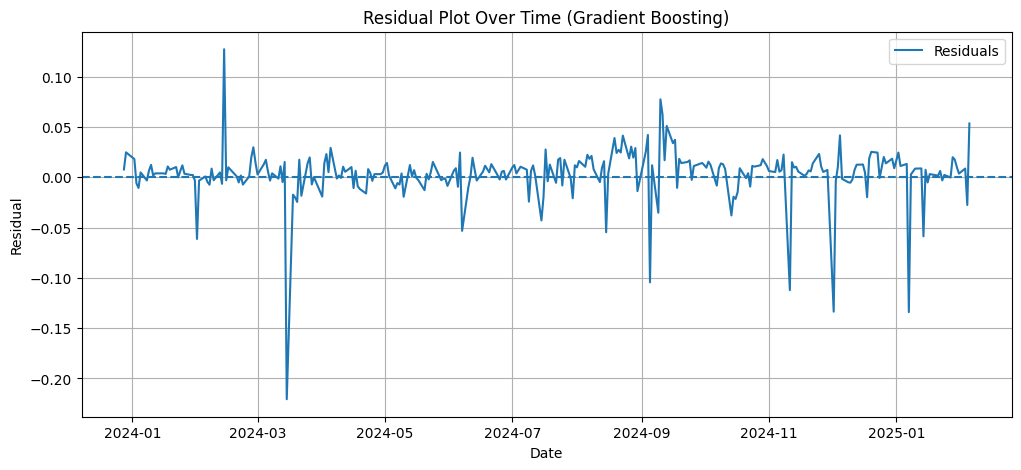

In [97]:
plt.figure(figsize=(12, 5))

plt.plot(residuals.index, residuals, label="Residuals")
plt.axhline(0, linestyle="--")

plt.title(f"Residual Plot Over Time ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.show()

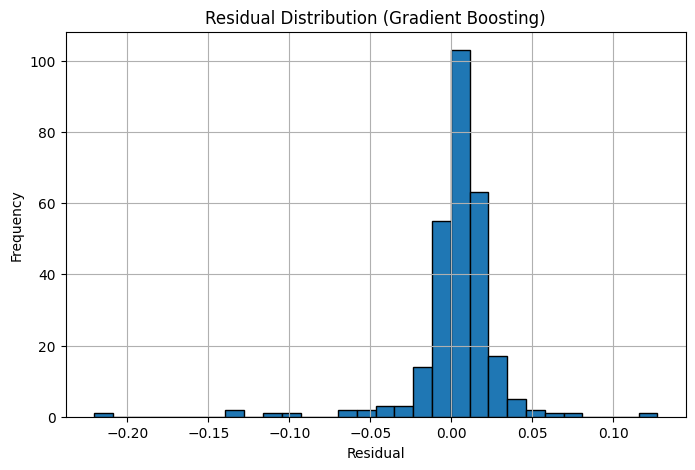

In [98]:
plt.figure(figsize=(8, 5))

plt.hist(residuals.dropna(), bins=30, edgecolor="black")

plt.title(f"Residual Distribution ({best_model_name})")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

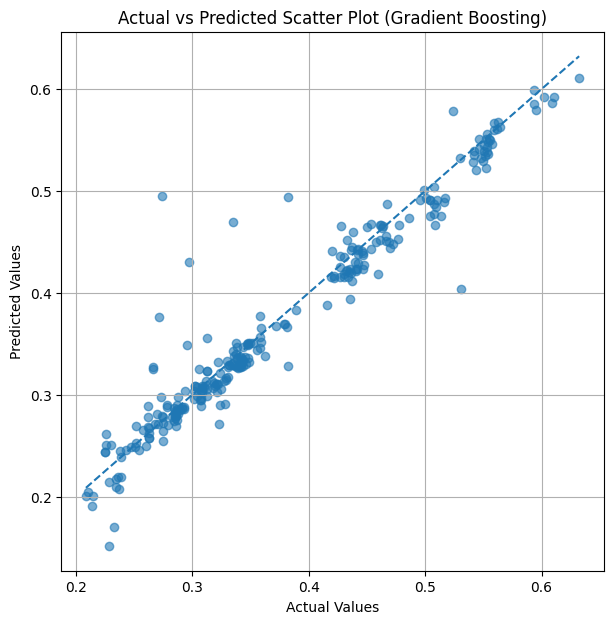

In [99]:
plt.figure(figsize=(7, 7))

plt.scatter(actual_aligned, pred_aligned, alpha=0.6)
plt.plot(
    [actual_aligned.min(), actual_aligned.max()],
    [actual_aligned.min(), actual_aligned.max()],
    linestyle="--"
)

plt.title(f"Actual vs Predicted Scatter Plot ({best_model_name})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.show()

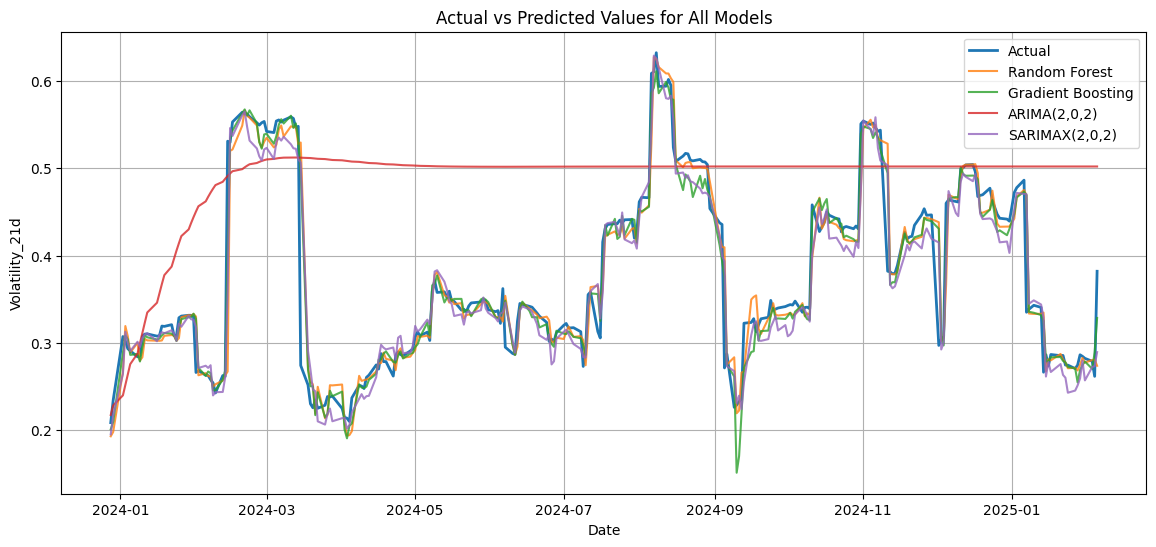

In [101]:
plt.figure(figsize=(14, 6))

plt.plot(dates_test, y_test, label="Actual", linewidth=2)

plt.plot(pd.Series(rf_pred, index=dates_test), label="Random Forest", alpha=0.8)
plt.plot(pd.Series(gb_pred, index=dates_test), label="Gradient Boosting", alpha=0.8)
plt.plot(pd.Series(arima_pred, index=y_test_ts.index), label="ARIMA(2,0,2)", alpha=0.8)
plt.plot(pd.Series(sarimax_pred, index=y_test_ts.index), label="SARIMAX(2,0,2)", alpha=0.8)

plt.title("Actual vs Predicted Values for All Models")
plt.xlabel("Date")
plt.ylabel("Volatility_21d")
plt.legend()
plt.grid(True)
plt.show()